# Main Title
- Author: Maurice Roots
- Date Created: 2026-06-08 17:46
- Last Updated: 2026-06-08 17:46
--- 


In [1]:
import time
_notebook_start = time.perf_counter()

In [2]:
import sys
from importlib import reload

from atmoz.surface.AirNow import AirNow
from atmoz.resources import useful_functions

reload(sys.modules['atmoz.surface.AirNow'])

<module 'atmoz.surface.AirNow' from 'E:\\Projects\\atmoz\\atmoz\\surface\\AirNow.py'>

In [3]:
import pickle
from pathlib import Path

filename = "AirNow_download.pkl"
if Path(filename).is_file():

    with open(filename, "rb") as f:
        surface = pickle.load(f)
else: 
    surface = AirNow.download(endpoint="aqs", parameters=["Ozone"], resolutions="hourly", years="2025")
    
    with open("AirNow_download.pkl", "wb") as f: 
        pickle.dump(surface, f)



In [4]:
[x for x in surface['hourly_44201_2025.csv'].columns]

['State Code',
 'County Code',
 'Site Num',
 'Parameter Code',
 'POC',
 'Latitude',
 'Longitude',
 'Datum',
 'Parameter Name',
 'Date Local',
 'Time Local',
 'Date GMT',
 'Time GMT',
 'Sample Measurement',
 'Units of Measure',
 'MDL',
 'Uncertainty',
 'Qualifier',
 'Method Type',
 'Method Code',
 'Method Name',
 'State Name',
 'County Name',
 'Date of Last Change']

In [5]:
import pandas as pd 

def _make_datetime(df: pd.DataFrame,
                   time_cols: dict = {
                       "date": "Date GMT", 
                       "time": "Time GMT", 
                       "format": {"date": "%Y-%m-%d ", "time": "%H:%M"}
                       },
                    **kwargs
                    ):
    
    if not isinstance(time_cols, dict):
        raise TypeError("argument (time_cols) must be of type dict")
    if not isinstance(df, pd.DataFrame):
        raise TypeError("argument (df) must be of type pd.DataFrame")
    
    datetime = pd.to_datetime(
        df[time_cols["date"]] 
        + " "
        + df[time_cols["time"]], 
        format = time_cols["format"]["date"] + time_cols["format"]["time"]
        )

    return datetime 

surface_temp = surface['hourly_44201_2025.csv'].copy()
surface_temp["Datetime"] = _make_datetime(surface_temp)


In [6]:
from typing import Any, Dict, List, Optional, Tuple, Union
from atmoz.resources.timeConversions import format_resolution
reload(sys.modules['atmoz.resources.timeConversions'])

import geopandas as gpd

def get_resolution(df: pd.DataFrame, col1: str, col2: str, col3: str, time_col: str = "Time GMT") -> pd.DataFrame:
    group_cols = [col1, col2, col3]
    results = []

    for key, group in df.groupby(group_cols, sort=False):
        group = group.sort_values(time_col).reset_index(drop=True)

        if len(group) < 2:
            resolution = "unknown"
        else:
            delta = group[time_col].iloc[1] - group[time_col].iloc[0]
            resolution = format_resolution(delta)

        row = dict(zip(group_cols, key if isinstance(key, tuple) else (key,)))
        row["resolution"] = resolution
        results.append(row)

    return pd.DataFrame(results)

def _get_stations(df: pd.DataFrame, lat_lon: List = ['Latitude', 'Longitude']) -> List[Tuple]:
    return df[lat_lon].drop_duplicates().apply(tuple, axis=1).tolist()

def _metadata(df: pd.DataFrame, 
              data_columns: List = [
                  'Date Local',
                  'Time Local', 
                  'Date GMT', 
                  'Time GMT', 
                  'Sample Measurement'
                  ],
                ID_cols: List = ["State Code", "County Code", "Site Num"],
                **kwargs):

    return df.drop(columns=data_columns).drop_duplicates(subset=ID_cols).reset_index(drop=True)

def to_gdf(df: pd.DataFrame, Latitude: str = "Latitude", Longitude: str = "Longitude", crs="EPSG:4326", **kwargs):
    geometry = gpd.points_from_xy(df[Longitude], df[Latitude])
    return gpd.GeoDataFrame(df, geometry=geometry, crs=crs, **kwargs)

def count_duplicates(df: pd.DataFrame, cols: list) -> None:
    found = False
    for combo in [cols[i:j] for i in range(len(cols)) for j in range(i+1, len(cols)+1)]:
        n = df.duplicated(subset=combo).sum()
        if n > 0:
            print(f"{combo} -> {n} duplicates")
            found = True
    if not found:
        print("No Duplicates")

In [7]:
df = surface_temp.copy() 
metadata = to_gdf(_metadata(df))
count_duplicates(metadata, cols=["Latitude", "Longitude"])

No Duplicates


### Making a Map of the EAP Sites

In [8]:
import plotly.graph_objects as go
from plotly.offline import iplot
import numpy as np

from itertools import cycle

colors = [
    "#CD6091",  # pink
    "#7195AB",  # steel blue
    "#6A4C93",  # purple
    "#4CC9F0",  # sky blue
    "#F4A261",  # orange
    "#2A9D8F",  # teal
    "#E76F51",  # burnt orange
    "#3A86FF",  # bright blue
    "#9B5DE5",  # violet
    "#8B3167",  # hot pink
]

def site_map(instruments: Dict,
             title: str = "Site Map",
             colors: list = colors,
             **kwargs
             ): 
    
    if not isinstance(instruments, Dict): 
        raise TypeError("'instruments' must be of type 'dict'")

    color_cycle = cycle(colors)

    params = {
        "bbox": {
            "lon": [-125.0, -66.9],
            "lat": [24.4, 49.4]
            },

        "title": {
            "text": title,
            "x": 0.5, "y": 0.98,
            "xanchor": "center",
            "font": dict(
                size=24,
                color="black",
                family="Arial Black"
                )
            },

        "map": {
            "zoom": 3,
            "bearing": 0,
            "pitch": 20,
            "domain": dict(x=[0, 1], y=[0, 1]),
            },

        "layout": {
            "height": 800,
            "width": 1600
            },
            
        "legend": dict(
            font=dict(size=18),
            itemsizing='constant',
            itemwidth=40,
            bgcolor='rgba(255,255,255,0.7)',
            x=0.01, y=0.99
            ),
        
        "Scattermap": {
            "mode": "markers",
            "marker": dict(size=15)
            },
        }
    
    params = useful_functions.merge_dicts(params, kwargs)
        
    fig = go.Figure()

    for name in instruments.keys():
        if not isinstance(instruments[name], gpd.GeoDataFrame):
            raise TypeError(f"'instruments' must be of type 'geopandas.GeoDataFrame'")

        trace_kwargs = {}
        hover_cols = kwargs.get("hover_cols", None)

        if hover_cols is not None:
            if isinstance(hover_cols, list):
                extra = "" if kwargs.get("show_trace_name", False) else "<extra></extra>"
                trace_kwargs = dict(
                    customdata=instruments[name][hover_cols],
                    hovertemplate="<br>".join(
                        f"<b>{col}</b>: %{{customdata[{i}]}}"
                        for i, col in enumerate(hover_cols)
                    ) + extra
                )

        marker = dict(params["Scattermap"]["marker"], color=params["Scattermap"]["marker"].get("color", next(color_cycle)))
        
        fig.add_trace(
            go.Scattermap( 
                lat=instruments[name].geometry.y,
                lon=instruments[name].geometry.x,
                name=name,
                mode=params["Scattermap"]["mode"],
                marker=marker,
                **trace_kwargs
                )
            )
        
    fig.update_layout(
        title=params["title"],
        map=dict(
            style="carto-positron",
            center=dict(
                lat=np.mean(params["bbox"]["lat"]),
                lon=np.mean(params["bbox"]["lon"])
                ),
            **params["map"],
            ),

        margin=dict(l=0, r=0, t=40, b=0),
        legend=params["legend"],
        showlegend=True,
        paper_bgcolor="rgba(255,255,255,0.7)",
        **params["layout"]
        )
    
    fig.show()
    return


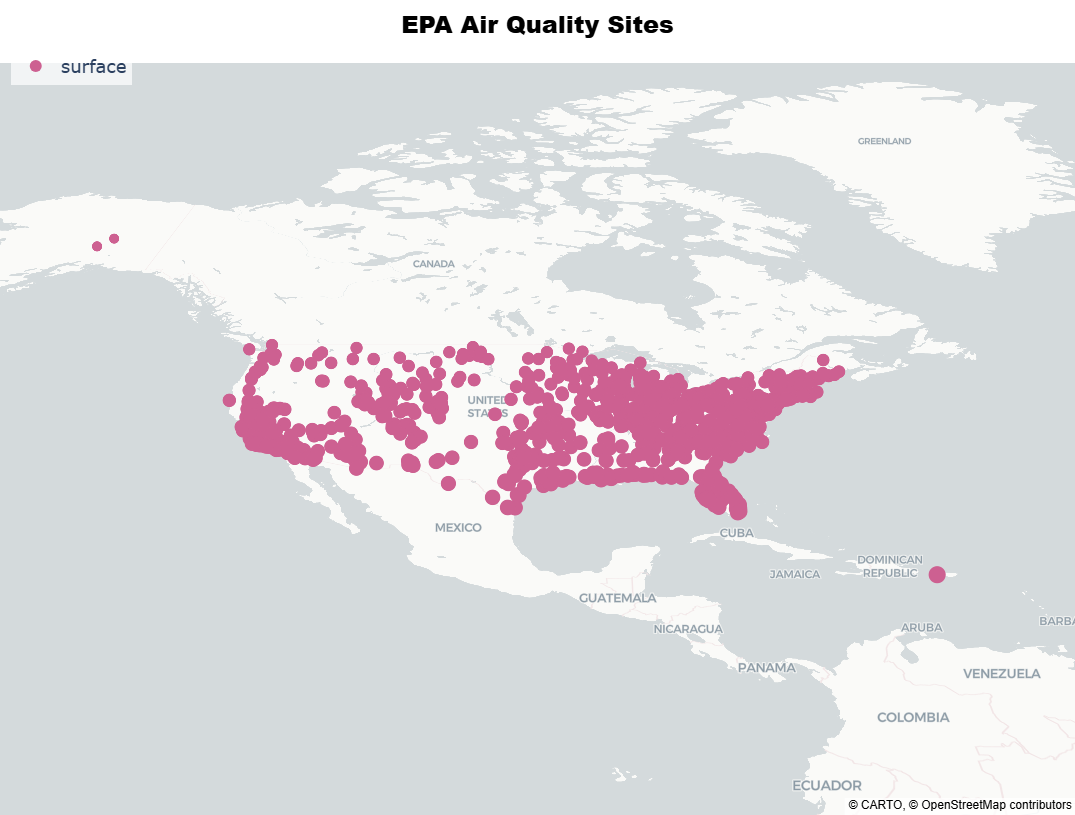

In [9]:
site_map(instruments={"surface": metadata}, title = "EPA Air Quality Sites", map = {"zoom": 3, "pitch": 60}, hover_cols=["Site Num", "State Name", "County Name", "Latitude", "Longitude", "Parameter Name"])

### GeoSlicing for a Specific Region

In [10]:
def slice_bbox(gdf: gpd.GeoDataFrame, bbox: list) -> gpd.GeoDataFrame:
    return (
        gdf.cx[
            bbox["lon"][0]:bbox["lon"][1],
            bbox["lat"][0]:bbox["lat"][1]
        ]
        .reset_index(drop=True)
        )


In [11]:
bbox = {
    "lon": [-80.0, -73.0],
    "lat": [36.5, 42.5]
}

midAtlantic = slice_bbox(metadata, bbox=bbox)

In [12]:
def _df_geo_slice(df: pd.DataFrame, gdf: gpd.GeoDataFrame, lat: str = "Latitude", lon: str = "Longitude") -> pd.DataFrame:
    coords = set(zip(gdf[lat], gdf[lon]))
    return df[pd.Series(zip(df[lat], df[lon])).isin(coords).values]

In [13]:
df_midAtlantic = _df_geo_slice(df, midAtlantic)

In [14]:
midAtlantic

,State Code,County Code,Site Num,Parameter Code,POC,Latitude,Longitude,Datum,Parameter Name,Units of Measure,...,Uncertainty,Qualifier,Method Type,Method Code,Method Name,State Name,County Name,Date of Last Change,Datetime,geometry
0,09,001,0017,44201,1,41.004657,-73.585128,NAD83,Ozone,Parts per million,...,NaN,NaN,FEM,087,INSTRUMENTAL - ULTRA VIOLET ABSORPTION,Connecticut,Fairfield,2025-07-03,2025-03-01 06:00:00,POINT (-73.58513 41.00466)
1,09,001,1123,44201,1,41.399167,-73.443056,WGS84,Ozone,Parts per million,...,NaN,NaN,FEM,087,INSTRUMENTAL - ULTRA VIOLET ABSORPTION,Connecticut,Fairfield,2025-07-03,2025-03-01 06:00:00,POINT (-73.44306 41.39917)
2,09,001,3007,44201,1,41.1525,-73.103056,WGS84,Ozone,Parts per million,...,NaN,NaN,FEM,087,INSTRUMENTAL - ULTRA VIOLET ABSORPTION,Connecticut,Fairfield,2025-07-03,2025-03-01 06:00:00,POINT (-73.10306 41.1525)
3,09,001,9003,44201,1,41.118333,-73.336667,WGS84,Ozone,Parts per million,...,NaN,NaN,FEM,087,INSTRUMENTAL - ULTRA VIOLET ABSORPTION,Connecticut,Fairfield,2025-07-03,2025-03-01 06:00:00,POINT (-73.33667 41.11833)
4,09,005,0005,44201,1,41.821342,-73.297257,WGS84,Ozone,Parts per million,...,NaN,XS,FEM,087,INSTRUMENTAL - ULTRA VIOLET ABSORPTION,Connecticut,Litchfield,2025-07-03,2025-01-01 06:00:00,POINT (-73.29726 41.82134)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126,51,800,0004,44201,1,36.90118,-76.43808,WGS84,Ozone,Parts per million,...,NaN,SX,FEM,047,INSTRUMENTAL - ULTRA VIOLET,Virginia,Suffolk City,2025-04-10,2025-03-01 05:00:00,POINT (-76.43808 36.90118)
127,51,800,0005,44201,1,36.66525,-76.73078,WGS84,Ozone,Parts per million,...,NaN,SX,FEM,047,INSTRUMENTAL - ULTRA VIOLET,Virginia,Suffolk City,2025-04-10,2025-03-01 05:00:00,POINT (-76.73078 36.66525)
128,54,003,0003,44201,1,39.448105,-77.963845,WGS84,Ozone,Parts per million,...,NaN,XS,FEM,160,INSTRUMENTAL - ULTRAVIOLET ABSORPTION,West Virginia,Berkeley,2025-06-13,2025-03-01 05:00:00,POINT (-77.96384 39.4481)
129,54,061,0003,44201,1,39.649444,-79.920278,WGS84,Ozone,Parts per million,...,NaN,XS,FEM,160,INSTRUMENTAL - ULTRAVIOLET ABSORPTION,West Virginia,Monongalia,2025-06-13,2025-03-01 05:00:00,POINT (-79.92028 39.64944)


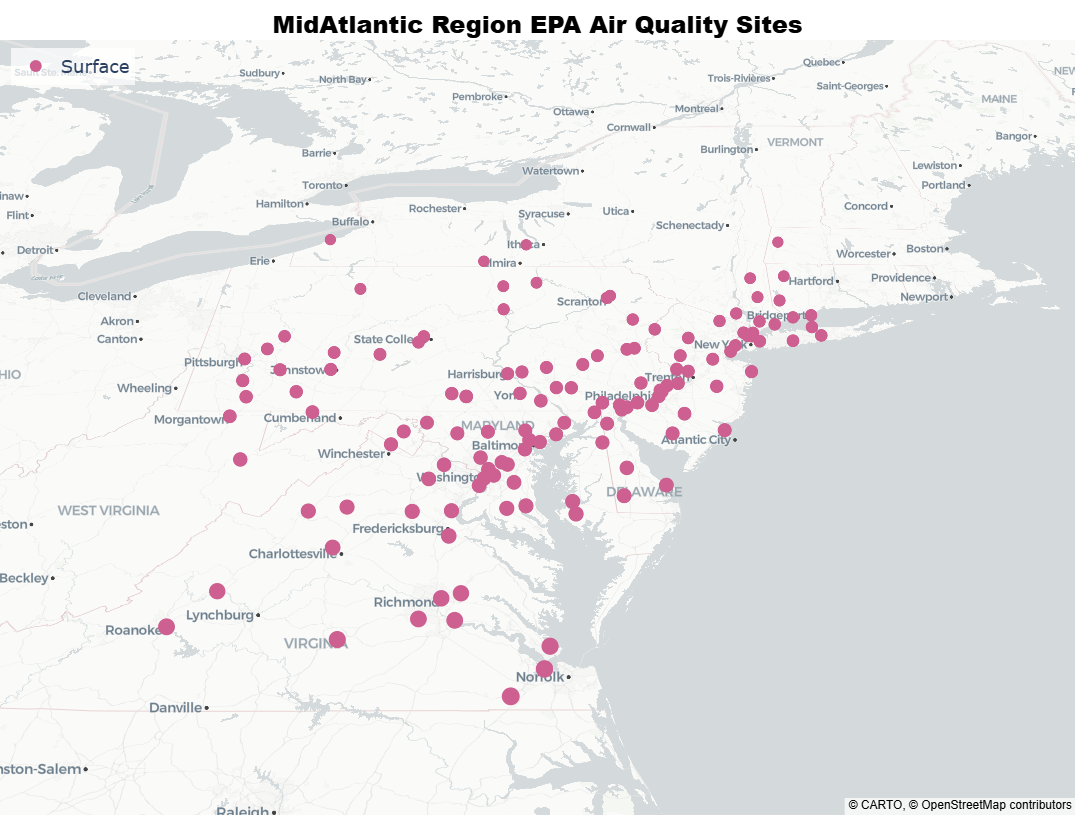

In [15]:
site_map(
    instruments={"Surface": midAtlantic},
    title = "MidAtlantic Region EPA Air Quality Sites", 
    map = {"zoom": 6, "pitch": 50},
    bbox= {"lon": [-80.0, -73.0], "lat": [36.5, 42.5]},
    hover_cols=[
        "State Code", 
        "County Code", 
        "Site Num", 
        "State Name", 
        "County Name", 
        "Latitude", 
        "Longitude", 
        "Parameter Name"
        ]
    )


In [16]:
def _split_parameters(df: pd.DataFrame, parameter_col: str = 'Parameter Name') -> dict:
    return {param: df[df[parameter_col] == param] for param in df[parameter_col].unique()}

In [17]:
dict_midAtlantic = _split_parameters(df_midAtlantic)

In [18]:
dict_midAtlantic.keys()

dict_keys(['Ozone'])

<Axes: xlabel='Datetime'>

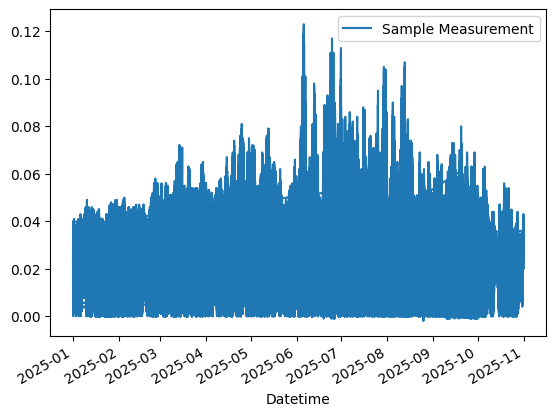

In [19]:
dict_midAtlantic["Ozone"].plot(x="Datetime", y="Sample Measurement")

In [20]:
# def time_series(x, y,
#                 plot_params: Dict = {}, 
#                 theme: Dict = {},
#                 show=True
#                 **kwargs
#                 ):
    
#     theme = useful_functions.merge_dicts(time_series_profile_theme, theme)
#     plot_params = useful_functions.merge_dicts(time_series_profile_params, plot_params)

#     with plt.rc_context(theme):
#         fig, ax = plt.subplots()

#     figure, ax = plt.figure()

#     plt.plot(x,y, "--o")

In [21]:
def split_by_station(df: pd.DataFrame, ID_cols: list = ["State Code", "County Code", "Site Num"]) -> dict:
    return {coords: group for coords, group in df.groupby(ID_cols)}

dict_midAtlantic_by_station = split_by_station(dict_midAtlantic["Ozone"])

In [23]:
# Helper Function to plot one (or many stations) at a time
#   Located by ("State Code", "County Code", "Site Num") 

import matplotlib.pyplot as plt 
from atmoz.resources import plot_utilities

timeseries_plot_theme = {
    # ime_Tick label font sizes
    "xtick.labelsize": 12,      # previously params["fontsize_ticks"]
    "ytick.labelsize": 12,

    # Axes labels
    "axes.labelsize": 14,       # previously params["fontsize_label"]

    # Title font
    "axes.titlesize": 16,       # previously params["title"]["fontsize"]
    "axes.titleweight": "bold",

    # Grid style
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.alpha": 0.7,
    "axes.grid.which": "both",

    # Minor ticks
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
    "xtick.minor.width": 0.5,
    "ytick.minor.width": 0.5,

    # Major ticks
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "xtick.major.width": 1,
    "ytick.major.width": 1,

    # Figure size (optional)
    "figure.figsize": (20, 6),

    # Fonts
    "font.family": "Courier New",
    "font.size": 14
    }

timeseries_theme = useful_functions.merge_dicts(timeseries_plot_theme, {
    "figure.figsize": (10, 6)
    })

timeseries_params = {
    "ax.legend": {
        "loc": "upper left",
        "fontsize": 12
        },

    "ax.set_ylabel": {
        "ylabel": "Value (units)"
        },

    "ax.set_xlabel": {
        "xlabel": "Time [UTC]"
        },

    "ax.set_title": {
        "label": "Timeseries Plot",
        "fontsize": 12
        },

    "ax.grid": {
        "visible": True,
        "color": "gray",
        "linestyle": "--",
        "linewidth": 0.5
        },

    "fig.layout": "tight",
    }

def timeseries_plot(dataset: dict, theme: dict = {}, plot_params: dict = {}, labels: dict = {}):
    theme = useful_functions.merge_dicts(timeseries_theme, theme)
    plot_params = useful_functions.merge_dicts(timeseries_params, plot_params)

    with plt.rc_context(theme):
        fig, ax = plt.subplots()

        for key, af in dataset.items():
            ax.plot(af.x, af.y, "--o", label = labels.get(key, key))
            break

        plot_utilities.apply_datetime_axis(ax)
        plot_utilities.apply_plot_params(fig, ax, **plot_params)
        plt.show()

    return {"figure": fig, "axis": ax}

In [24]:
stations = [("24", "033", "0030")]
datasets = {f"{item["County Name"].iloc[0]}, {item["State Name"].iloc[0]}": item for key, item in dict_midAtlantic_by_station.items() if key in stations}

In [25]:
from atmoz.dataclasses import AtmoFrame
from atmoz.dataclasses import AtmoDataset

average_8hour = {}
for key, df in datasets.items(): 
    average_8hour[key] = AtmoFrame(
        df[["Sample Measurement", "Datetime"]].resample(rule="8h", on="Datetime").mean().reset_index(),
        y="Sample Measurement", x="Datetime"
        )
    break

In [28]:
dataset = {key: AtmoFrame(df=item, x="Datetime", y="Sample Measurement") for key, item in datasets.items()}
AtmoDataset(frames=dataset, name="surface", source="EPA_PreGen")

E:\Projects\atmoz\.venv\Lib\site-packages\IPython\core\formatters.py:429: FormatterWarning: text/html formatter returned invalid type <class 'atmoz.dataclasses.AtmoDataset._BroadcastProxy'> (expected <class 'str'>) for object: AtmoDataset(name='surface', source='EPA_PreGen', time=2025-01-01 06:00:00 → 2025-11-01 04:00:00, n_frames=1, frames=["Prince George's, Maryland"])
  warnings.warn(
E:\Projects\atmoz\.venv\Lib\site-packages\IPython\core\formatters.py:429: FormatterWarning: text/latex formatter returned invalid type <class 'dict'> (expected <class 'str'>) for object: AtmoDataset(name='surface', source='EPA_PreGen', time=2025-01-01 06:00:00 → 2025-11-01 04:00:00, n_frames=1, frames=["Prince George's, Maryland"])
  warnings.warn(


AtmoDataset(name='surface', source='EPA_PreGen', time=2025-01-01 06:00:00 → 2025-11-01 04:00:00, n_frames=1, frames=["Prince George's, Maryland"])

In [ ]:
test = AtmoFrame(df, x="Datetime")

In [ ]:
timeseries_plot(average_8hour)

In [ ]:
elapsed = time.perf_counter() - _notebook_start
print(f"Notebook ran in {elapsed:.2f}s")

i love coding omg and kat is awesome and she is the best girlfriend. Peace and Love kissyface. 